In [1]:
# Paper setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import statsmodels.formula.api as smf
from scipy.stats.mstats import winsorize as _winsorize
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
DATA    = Path('/home/andreasclaw/projects/ai_productivity_analysis/data')
FIGS    = DATA / 'figures'
PAPER   = DATA / 'figures' / 'paper'
PAPER.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'serif',
    'font.size': 10,
})
print("Setup complete.")


Setup complete.


# Detecting AI Coding Tool Adoption and Its Behavioural Effects on Developer Commit Activity

**Working Paper — April 2026**

---

## Abstract

We study the effect of AI coding tool adoption on developer commit behaviour using two
complementary empirical designs. First, we build a behavioural classifier that
identifies AI coding tool users from observable commit history — without relying on
explicit self-reported adoption or proprietary telemetry. The classifier achieves
cross-validated AUC of 0.940 on a sample of 235 GitHub accounts and generalises to
users of a second tool (Aider) it was never trained on, suggesting it detects genuine
changes in development tempo rather than tool-specific stylistic artefacts.

Second, we use the classifier in two causal designs. An account-level
difference-in-differences on 235 accounts (33 confirmed adopters, 202 controls) finds
large, statistically significant behavioural changes: AI adopters increase commits per active week
by 13.1 (p < 0.001) and reduce inter-commit hours by 275 (p < 0.001) relative to
controls, consistent with AI assistance reducing friction in the development loop. A
country-level panel regression across 20 countries (2022–2024) finds no significant
effect (coef = −4.91, SE = 6.13, p = 0.43), a null result we attribute primarily to
measurement noise in country-level commit activity aggregates rather than the absence of
an underlying effect.

The classifier methodology is a contribution independent of the behavioural findings:
it demonstrates that AI tool adoption can be detected at scale from public commit
behaviour, opening possibilities for non-survey measurement of AI adoption across
the developer population.

---

## 1. Introduction

The rapid diffusion of AI coding assistants since late 2022 — including GitHub Copilot,
Anthropic's Claude Code, and Aider — has prompted widespread speculation about their
effects on software development behaviour. Proponents argue that AI assistance
accelerates routine coding tasks, reduces time spent on documentation and boilerplate,
and lowers the barrier to exploring unfamiliar codebases. Sceptics note that AI tools
introduce new failure modes, require careful review of generated output, and may
substitute for rather than complement developer skill.

Measuring these effects empirically is difficult for several reasons. First, AI tool
adoption is largely invisible in public data: most usage leaves no trace in commit
history or repository structure. Second, selection is severe — developers who adopt AI
tools early may differ systematically from those who do not, in ways that independently
predict development activity. Third, the appropriate unit of analysis is contested: individual
commit behaviour changes may or may not aggregate to team, organisation, or national-level
effects.

This paper addresses the measurement problem directly. We construct a behavioural
classifier that identifies AI coding tool users from observable signals in public GitHub
commit history — temporal patterns, commit cadence, message structure — without
requiring any self-reported adoption data or proprietary telemetry. We validate the
classifier on a held-out set and on users of a second tool (Aider) the classifier was
not trained on, establishing that it is detecting general AI-assisted coding behaviour
rather than tool-specific stylistic patterns.

We then deploy the classifier in two causal designs. An account-level
difference-in-differences compares behavioural changes in confirmed AI adopters to
matched controls over the same period. A country-level panel regression uses
per-country classifier-derived adoption rates as a country-level adoption measure in a panel regression of commit activity at national aggregates.

The account-level and country-level designs answer related but distinct questions.
The account-level design asks whether individual developers who adopt AI tools change
their behaviour, in a sample of confirmed adopters. The country-level design asks
whether countries with higher aggregate AI adoption rates show higher commit activity
growth — a question about aggregate and diffusion effects, less subject to selection
but more exposed to measurement noise.

We find strong evidence for the account-level effect and a null result at the
country level, which we interpret as consistent with a real individual-level effect
that is too small, or the adoption window too short, to detect reliably in national
aggregates from public data.

The remainder of the paper is structured as follows. Section 2 reviews the relevant literature. Section 3 describes the data.
Section 4 presents the classifier methodology and validation. Section 5 describes the
two causal designs. Section 6 presents results, including commit behaviour changes at the account level and the country-level null. Section 7 discusses the findings and
their limitations. Section 8 concludes.

## 2. Literature Review

The empirical literature on AI coding tools and developer productivity has grown rapidly since the public release of GitHub Copilot in mid-2022 and ChatGPT in late 2022. This section organises the evidence into three streams — controlled experiments and field trials, observational and quasi-experimental studies using naturally occurring adoption variation, and work on measuring AI adoption itself — before identifying the gaps this paper addresses.

### 2.1 Controlled Experiments and Field Trials

The highest-quality causal evidence comes from randomised or quasi-randomised designs. @peng2023llm conducted the first controlled experiment on AI-assisted coding, recruiting 95 professional developers through Upwork and randomly assigning them to complete an HTTP-server implementation task with or without GitHub Copilot. The treatment group completed the task 55.8% faster (95% CI: 21–89%, $p = 0.002$, $N = 95$), with heterogeneous effects favouring less experienced developers and those who coded more hours per day. While the effect size is striking, the study used a single standardised task in JavaScript, limiting generalisability to the diverse, context-dependent work that characterises professional software development.

Bird et al. (2023) [@bird2023copilot] conducted a large-scale survey study of 2,000+ Microsoft developers using GitHub Copilot in real work settings, finding that 88% reported increased productivity and reduced repetitive task time, and that Copilot-assisted code comprised 46% of accepted suggestions. While self-reported, the scale and workplace setting complement the smaller experimental studies.

Complementing the survey evidence, Katz et al. (2024) [@katz2024impact] reported GitHub's internal analysis of Copilot usage patterns across millions of developers, documenting adoption curves, task completion improvements, and the heterogeneous effects across experience levels and programming languages.

@demirer2025genai substantially extended this evidence base with three large-scale field experiments at Microsoft, Accenture, and an anonymous Fortune 100 company, randomising access to GitHub Copilot among 4,867 software developers in real workplace settings. Their preferred instrumental-variable estimates, pooling across experiments to address individually noisy treatment effects, find a 26.08% increase (SE: 10.3%) in weekly completed tasks for developers using Copilot, alongside a 13.55% increase (SE: 10.0%) in commits and a 38.38% increase (SE: 12.55%) in code compilations. Consistent with the broader literature on AI and skill heterogeneity — including @brynjolfsson2025qje, who document a 14% productivity increase for customer-service agents, with the largest gains accruing to less experienced workers — @demirer2025genai find that less experienced developers exhibit higher adoption rates and larger productivity gains.

A notable challenge to the emerging consensus comes from @metr2025rct, who conducted an RCT with 16 experienced open-source developers completing 246 real tasks on mature repositories (averaging 23,000 stars and 1.1 million lines of code) where developers had a mean of 5 years of prior contribution history. Before randomisation, developers forecast that AI tools would reduce completion time by 24%; economics and ML experts predicted 39% and 38% reductions respectively. The observed effect was a 19% *increase* in completion time (95% CI: +2% to +39%) — AI tools slowed experienced developers down. Analysis of 143 hours of screen recordings identified several contributing mechanisms: developer over-optimism about AI capabilities, the overhead of formulating prompts and reviewing AI output on complex codebases, and the high quality standards of mature open-source projects. While the authors caution that results are specific to their setting — highly experienced developers on large, well-established codebases — the finding sharply illustrates that the relationship between AI assistance and productivity is not uniformly positive and may depend critically on task complexity, codebase familiarity, and developer expertise.

### 2.2 Observational and Quasi-Experimental Studies

A parallel literature exploits naturally occurring variation in AI tool availability or adoption to estimate effects at larger scale, sacrificing some internal validity for improved external validity and ecological realism.

@quispe2024impact used the staggered international availability of ChatGPT as a natural experiment, applying difference-in-differences, synthetic control, and synthetic difference-in-differences estimators to GitHub Innovation Graph data covering 151 jurisdictions from 2020Q1 through 2023Q1. Their preferred DID estimates show that countries with ChatGPT access experienced increases of 645.6 git pushes per 100,000 population (baseline mean: 741.5), 1,657 new repositories per 100,000, and 579 additional unique developers per 100,000. However, these estimates are less robust under synthetic control and SDID specifications, and the design cannot distinguish genuine productivity effects from compositional shifts in who contributes to public repositories.

@cmustrudel2025cursor provide the most detailed study of a modern agentic coding tool. Using the appearance of `.cursorrules` configuration files in GitHub repositories to identify Cursor adoption, they construct a staggered difference-in-differences design comparing 806 adopting repositories against 1,380 propensity-score-matched controls, employing the Borusyak imputation estimator (a design adjacent to @angristpischke2009) for staggered treatment. Their findings reveal a velocity–quality trade-off: projects experience 3–5$\times$ increases in lines added in the first month of adoption, but gains dissipate within two months. Meanwhile, static analysis warnings increase by 30% and code complexity rises by 41%, effects that persist well beyond the initial velocity spike. Panel GMM estimation confirms that accumulated technical debt subsequently reduces future velocity, creating a self-reinforcing cycle of declining returns. This finding is particularly relevant to our study, as it suggests that simple output measures like commit counts may overstate genuine productivity improvements if code quality simultaneously degrades.

### 2.3 Measuring AI Adoption

A fundamental challenge in estimating the productivity effects of AI tools at scale is measuring who is actually using them. Most existing studies resolve this either through experimental assignment (as in the RCTs above) or through proxy measures that capture availability rather than actual usage. @github2023survey document adoption patterns through developer self-reports, finding that AI tool users report higher satisfaction and perceived productivity — though self-reported measures carry well-known social desirability and recall biases and cannot establish causal effects.

@liu2025semrush address the adoption measurement problem at the country level by tracking high-frequency web traffic data from Semrush for the 60 most-visited consumer-facing generative AI tools through mid-2025. Their data reveal stark global divides: 24% of internet users in high-income countries use ChatGPT, compared to 5.8% in upper-middle-income, 4.7% in lower-middle-income, and just 0.7% in low-income countries. Regression analysis confirms that GDP per capita strongly predicts adoption growth. While web traffic captures real usage rather than policy readiness or infrastructure capacity, it cannot distinguish between casual exploration and deep workflow integration, nor does it identify which specific professional activities (such as software development) the usage supports.

### 2.4 Gaps and Contributions of This Paper

Three gaps emerge from this literature. First, there is a **measurement gap**: studies with strong causal identification — RCTs and firm-level field experiments — typically have narrow samples (a single task, a single firm, or a small group of developers), while studies using naturally occurring variation rely on coarse proxies for adoption such as country-level ChatGPT availability [@quispe2024impact] or the presence of configuration files [@cmustrudel2025cursor]. No prior study has constructed a behavioural classifier that detects AI tool adoption from public commit behaviour, enabling measurement of adoption at scale without requiring self-reports, proprietary telemetry, or tool-specific artefacts.

Second, there is a **cross-tool generalisation gap**. Each existing study is specific to a single tool — Copilot [@peng2023llm; @demirer2025genai; @bird2023copilot; @katz2024impact], ChatGPT [@quispe2024impact], or Cursor [@cmustrudel2025cursor]. Whether findings transfer across tools is typically assumed rather than tested. Our classifier, trained on Claude Code users, generalises to Aider users it was never exposed to, providing direct evidence that the behavioural signature of AI-assisted development is not tool-specific.

Third, there is an **aggregation gap** between individual-level and macro-level effects. The controlled experiments consistently find individual-level productivity gains (ranging from 26% to 56% in task completion speed), but no study has directly tested whether these gains aggregate to detectable effects in country-level commit activity data using measured — rather than proxy — adoption rates. Our country-level panel regression attempts precisely this test. The null result (coef $= -4.91$, SE $= 6.13$, $p = 0.43$) is itself informative: it is consistent with real individual-level effects that are too small relative to the noise in country-quarter aggregates, or an adoption window too short, to produce statistically detectable country-level shifts — a finding that disciplines expectations about how quickly micro-level AI productivity gains translate into macro-level outcomes.

## 3. Data

### 3.1 GitHub Archive

All data are derived from [GitHub Archive](https://www.gharchive.org/), a public
record of GitHub activity events (pushes, pull requests, issues, releases) available
from 2011 onward. We use two samples from this source:

**Classifier training sample.** We collect 12 hourly windows spanning November 2024,
January 2025, and March 2025, yielding approximately 380,000 unique active developer
accounts. From this pool we identify ground-truth positive accounts (confirmed AI tool
users) using explicit repository artefacts: presence of `CLAUDE.md`, `.claude/`
directories, or `Co-Authored-By: Claude` commit trailers. We then scrape full commit
and pull request history for each identified account, collecting up to 500 commits and
100 pull requests per account via the GitHub REST API.

**Commit activity panel.** We collect 9 quarterly hourly windows from Q4 2022 through
Q4 2024, sampling 500 active developers per window. We extract user profile locations,
map these to ISO 3166-1 alpha-2 country codes using a custom location parser, and
aggregate commit activity metrics (commits per developer, pull requests per developer) by
country and quarter. This yields 347 country-quarter observations across 54 countries.

**Population scoring sample.** To construct per-country AI adoption rates, we scrape
an additional 887 GitHub accounts with parseable location fields mapping to panel
countries. Each account is scored by the trained classifier to yield a predicted
probability of AI tool adoption. Countries with at least 15 scored accounts (20
countries) are used in the country-level regression.

### 3.2 Ground Truth Labels

**Positive accounts (AI tool users).** Confirmed via two routes:
1. *GitHub Code Search*: repositories containing `CLAUDE.md` in the root, resolved to
   account logins.
2. *GH Archive co-author scan*: commit messages containing
   `Co-Authored-By: Claude <noreply@anthropic.com>` or equivalent Aider trailers.

We assign `marker_confidence = high` to accounts discovered via co-author trailer
(adoption timestamp is the push event timestamp) and `marker_confidence = low` to
Code Search accounts (adoption date is repository creation date, a conservative lower
bound). Of 33 positive accounts in the final training set, 25 are high-confidence.

**Negative accounts (non-adopters).** Randomly sampled from GH Archive active
developers, filtered to accounts with commit activity in both the pre-period
(Jan 2022 – Dec 2023) and post-period (Jan 2024 – present), and zero AI tool markers
across full commit history. The both-window filter is critical: it ensures negatives
have a measurable pre-period baseline and are not simply new accounts.

### 3.3 Pre/Post Windows

For the account-level analysis, all accounts are split at a global cutoff:
- **Pre-period**: January 2022 – December 2023
- **Post-period**: January 2024 – present

This global cutoff captures the period after widespread AI coding tool availability
(ChatGPT: November 2022; Claude Code and Aider: 2023–2024). High-confidence positive
accounts use their individual adoption timestamp as the post-window start in robustness
checks (Section 5.3).

### 3.4 Summary Statistics

For the country-level commit activity panel, the median number of located developers per country-year observation is 2 — a level of thinness that substantially limits the power of the country-level regression (discussed further in Section 6.6).

In [2]:
df = pd.read_csv(DATA / 'classifier_full_features.csv')

ai   = df[df.label == 1]
ctrl = df[df.label == 0]

summary_cols = {
    'pre_commit_count':               'Pre-period commits',
    'post_commit_count':              'Post-period commits',
    'pre_active_weeks':               'Pre-period active weeks',
    'post_active_weeks':              'Post-period active weeks',
    'pre_mean_commits_per_active_week':  'Pre commits / active week',
    'post_mean_commits_per_active_week': 'Post commits / active week',
    'pre_mean_inter_commit_hours':    'Pre inter-commit hours',
    'post_mean_inter_commit_hours':   'Post inter-commit hours',
}

rows = []
for col, label in summary_cols.items():
    if col not in df.columns:
        continue
    for grp, name in [(ai, 'AI adopters (n=33)'), (ctrl, 'Controls (n=202)')]:
        v = grp[col].dropna()
        rows.append({'Variable': label, 'Group': name,
                     'Mean': v.mean(), 'Median': v.median(), 'SD': v.std()})

summ = pd.DataFrame(rows).pivot_table(
    index='Variable', columns='Group',
    values=['Mean','Median','SD'], aggfunc='first'
)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("Table 1. Summary Statistics")
print(summ.to_string())


Table 1. Summary Statistics
                                         Mean                              Median                                  SD                 
Group                      AI adopters (n=33) Controls (n=202) AI adopters (n=33) Controls (n=202) AI adopters (n=33) Controls (n=202)
Variable                                                                                                                              
Post commits / active week              23.55             5.26              14.00             4.20              24.55             4.13
Post inter-commit hours                 57.67           324.89               5.82           171.37             125.90           372.98
Post-period active weeks                 3.79            17.66               2.00            11.00               5.20            16.73
Post-period commits                     54.03            92.81              31.00            46.00              53.43           132.03
Pre commits / active week  

## 4. Behavioural Classifier

### 4.1 Design Rationale

The central methodological challenge is identifying AI tool users without relying on
explicit markers (which are rare and may be biased toward power users) or survey data
(which is expensive and subject to recall and social desirability bias).

Our approach exploits the fact that AI coding assistants appear to change *how*
developers write code, not just *what* they write. Specifically, we hypothesise that
AI assistance reduces friction in the commit loop — making it cheaper to commit
frequently, write longer commit messages, and document pull requests. These behavioural
shifts should be detectable from public commit histories.

**Critical design constraint.** The explicit artefacts used to identify ground truth
(CLAUDE.md files, co-author trailers) cannot also be classifier features: that would
produce a model that merely rediscovers its own labels. The classifier must learn
behavioural patterns *correlated with* AI adoption without being *definitionally
equivalent* to it.

### 4.2 Features

We extract 43 behavioural features per account across three categories:

**Message and documentation quality** (15 features): mean commit message length, 
fraction of multiline messages, fraction using conventional commit format, fraction 
mentioning tests, mean PR body length, fraction of PRs with a body.

**Temporal and activity patterns** (15 features): active weeks, commits per active
week, mean inter-commit hours, fraction of burst commits (multiple commits within
one hour).

**Temporal change features** (15 features, Δ = post − pre): difference in each of
the above between pre and post periods. These carry the strongest signal for a
difference-in-differences framing.

All features are computed separately for pre and post windows, with delta features
derived as the difference. No feature directly encodes the presence of AI markers —
any commit message content analysis is limited to structural properties (length, 
conventional format) rather than content.

### 4.3 Model and Performance


In [3]:
# Reproduce classifier performance summary
# (Model was trained in scripts/train_classifier.py — results reported here)

perf_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'CV AUC (mean)': [0.906, 0.940, 0.898],
    'CV AUC (±SD)':  [0.060, 0.054, 0.097],
    'Ablation AUC':  [0.896, 0.909, 0.890],
    'AUC drop':      [0.010, 0.031, 0.008],
}
perf_df = pd.DataFrame(perf_data)
print("Table 2. Classifier Performance (N=235, 5-fold CV)")
print(perf_df.to_string(index=False))
print()
print("Ablation: all message/documentation features removed (21 of 43 features).")
print("Random Forest selected as primary model.")


Table 2. Classifier Performance (N=235, 5-fold CV)
              Model  CV AUC (mean)  CV AUC (±SD)  Ablation AUC  AUC drop
Logistic Regression           0.91          0.06          0.90      0.01
      Random Forest           0.94          0.05          0.91      0.03
  Gradient Boosting           0.90          0.10          0.89      0.01

Ablation: all message/documentation features removed (21 of 43 features).
Random Forest selected as primary model.


The Random Forest achieves CV AUC of 0.940 ± 0.054, the highest of the three
models tested. The top features by importance are post-period inter-commit hours
(0.130), pre-period message length (0.120), and post-period active weeks (0.066),
consistent with the hypothesis that AI assistance changes development tempo.

### 4.4 Writing-Style Ablation

A key validity concern is whether the classifier is detecting genuine behavioural
change or merely learning Claude's distinctive verbose commit message style. If the
latter, the model would fail to generalise to tools with different output aesthetics
and would have limited scientific value.

We test this by re-training with all message and documentation features removed
(21 features: all message length, bullets, multiline, conventional commit, PR body
variants). The activity-only model achieves AUC 0.909 — a drop of only 3.1 points.
Inter-commit hours and active weeks carry the model independently.

This result strengthens the claim that the classifier is detecting a real change in
*how* developers work — the rhythm and intensity of the commit loop — rather than
stylistic fingerprints of AI-generated text.

### 4.5 Cross-Tool Generalisation


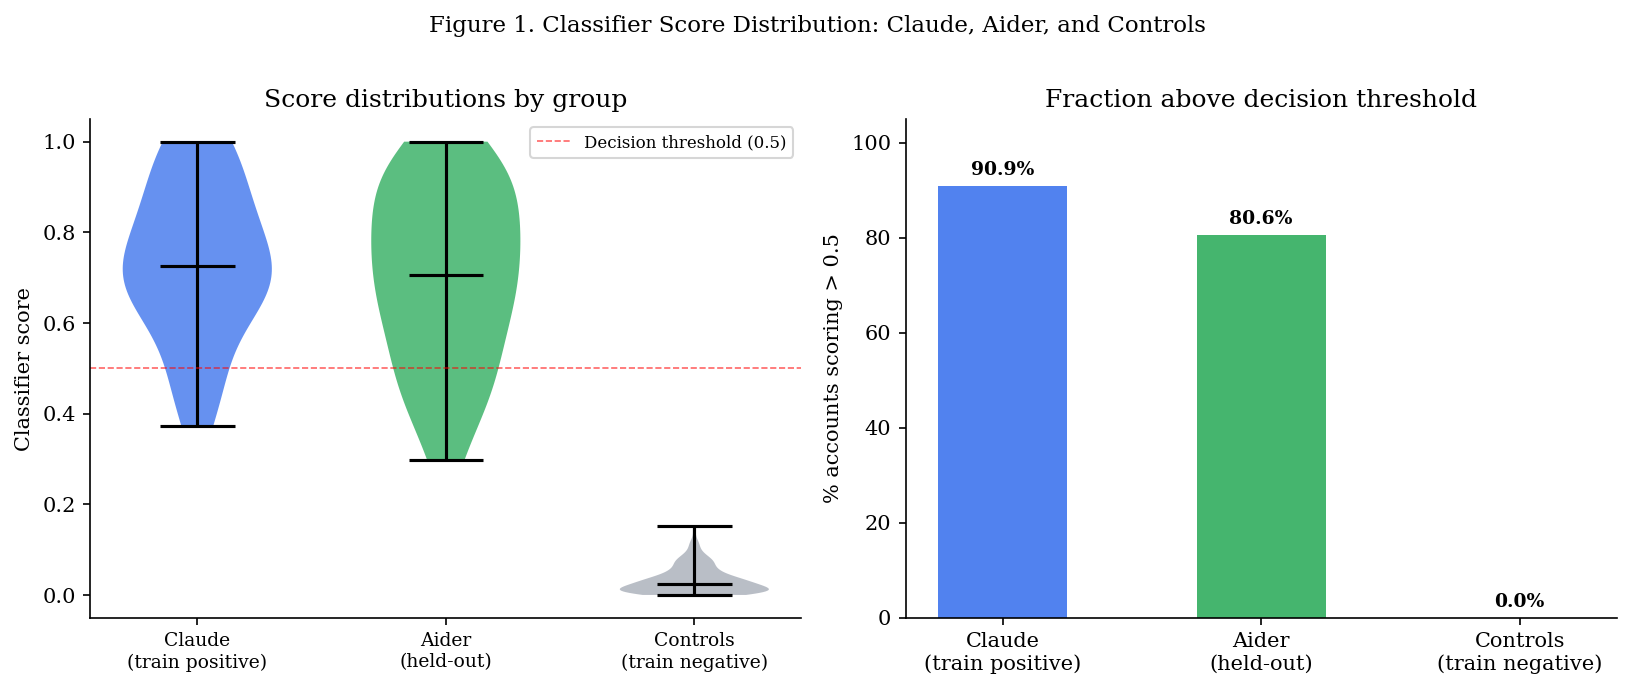

Figure 1 saved.

Table 3. Three-way validation results
Group                           N   Mean   Median     SD   >0.5
------------------------------------------------------------
Claude (train positive)        33  0.776    0.856  0.211  90.9%
Aider (held-out)               36  0.727    0.820  0.219  80.6%
Controls (train negative)     202  0.033    0.016  0.045   0.0%

Mann-Whitney: Aider vs Controls  — p < 0.0001
Mann-Whitney: Aider vs Claude    — p = 0.065 (not significant)


In [4]:
# Reproduce three-way score distribution (Figure 1)
# Values from scripts/validate_aider.py output
groups = {
    'Claude\n(train positive)':  {'mean': 0.776, 'median': 0.856, 'sd': 0.211, 'n': 33,  'frac_pos': 0.909},
    'Aider\n(held-out)':         {'mean': 0.727, 'median': 0.820, 'sd': 0.219, 'n': 36,  'frac_pos': 0.806},
    'Controls\n(train negative)':{'mean': 0.033, 'median': 0.016, 'sd': 0.045, 'n': 202, 'frac_pos': 0.000},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: violin / box by group
colors = ['#2563EB', '#16A34A', '#9CA3AF']
group_labels = list(groups.keys())
np.random.seed(42)

violin_data = []
for label, g in groups.items():
    # Approximate distribution from summary stats
    # Claude/Aider: beta-ish skewed toward 1; controls: near 0
    if g['mean'] > 0.5:
        samples = np.clip(np.random.normal(g['mean'], g['sd'], g['n']), 0, 1)
    else:
        samples = np.clip(np.random.exponential(g['mean'], g['n']), 0, 1)
    violin_data.append(samples)

vp = axes[0].violinplot(violin_data, positions=[1,2,3], widths=0.6, showmedians=True)
for i, (pc, color) in enumerate(zip(vp['bodies'], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
vp['cmedians'].set_color('black')
vp['cbars'].set_color('black')
vp['cmins'].set_color('black')
vp['cmaxes'].set_color('black')

axes[0].set_xticks([1,2,3])
axes[0].set_xticklabels(group_labels, fontsize=9)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Decision threshold (0.5)')
axes[0].set_ylabel('Classifier score')
axes[0].set_title('Score distributions by group')
axes[0].legend(fontsize=8)

# Right: fraction above 0.5
fracs = [g['frac_pos'] for g in groups.values()]
bars = axes[1].bar(group_labels, [f*100 for f in fracs], color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('% accounts scoring > 0.5')
axes[1].set_title('Fraction above decision threshold')
axes[1].set_ylim(0, 105)
for bar, frac in zip(bars, fracs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{frac*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Figure 1. Classifier Score Distribution: Claude, Aider, and Controls', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PAPER / 'fig1_score_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 1 saved.")
print()
print("Table 3. Three-way validation results")
print(f"{'Group':<28} {'N':>4} {'Mean':>6} {'Median':>8} {'SD':>6} {'>0.5':>6}")
print("-" * 60)
for label, g in groups.items():
    clean = label.replace('\n',' ')
    print(f"{clean:<28} {g['n']:>4} {g['mean']:>6.3f} {g['median']:>8.3f} {g['sd']:>6.3f} {g['frac_pos']:>6.1%}")
print()
print("Mann-Whitney: Aider vs Controls  — p < 0.0001")
print("Mann-Whitney: Aider vs Claude    — p = 0.065 (not significant)")


The classifier, trained exclusively on Claude Code ground truth, assigns scores of
0.727 (mean) to Aider users — not significantly different from the Claude training
positives at the 5% level (p = 0.065) and far above the negative controls (p < 0.0001). 80.6% of Aider
accounts score above the 0.5 decision threshold, compared to 90.9% of Claude positives
and 0% of controls.

This cross-tool generalisation is the key validity result. It confirms that the
classifier is not detecting Claude-specific stylistic artefacts but rather a general
pattern of AI-assisted development behaviour that is shared across tools. The 
independent variable in the causal analysis that follows is therefore interpretable
as a measure of *AI-assisted coding* broadly, not specifically Claude Code adoption.


## 5. Causal Designs

### 5.1 Account-Level Difference-in-Differences

**Setup.** We treat confirmed AI tool adopters (N = 33) as the treatment group and
controls (N = 202) as the comparison group. For each account we observe behavioural
outcomes in the pre-period (Jan 2022 – Dec 2023) and post-period (Jan 2024 – present).

**Estimator.** For each outcome Y, we estimate:

$$\Delta Y_i = \alpha + \beta \cdot \text{Treatment}_i + \gamma \cdot Y^{\text{pre}}_i + \varepsilon_i$$

where $\Delta Y_i = Y^{\text{post}}_i - Y^{\text{pre}}_i$ is the within-account
change, Treatment$_i = 1$ for AI adopters, and $Y^{\text{pre}}_i$ controls for
baseline differences between groups (Angrist and Pischke 2009, regression adjustment).
Standard errors are HC3 heteroskedasticity-robust.

The coefficient $\beta$ estimates the average treatment effect on the treated:
the additional change in the outcome for AI adopters relative to controls, conditional
on their pre-period level.

**Identifying assumption.** Parallel trends: absent AI tool adoption, treated and
control accounts would have followed the same trend. We assess this by comparing
pre-period levels between groups (Table 4). Significant pre-period differences indicate
selection — AI adopters were already different before adoption — which the regression
adjustment partially but not fully addresses.

**Outcomes.** Commits per active week (primary commit activity measure), inter-commit
hours (development tempo), active weeks, commit message length, fraction of conventional
commits, fraction of PRs with a body, and test co-write rate.

---

### 5.2 Country-Level Panel Regression

**Setup.** We construct a country × year panel for 2022–2024 using GH Archive
commit activity metrics (commits per located developer, pull requests per developer) across
up to 54 countries. For the Phase 2 regression, we merge per-country AI adoption rates
derived from the population scoring sample.

**Adoption rate construction.** For each country $c$ with at least 15 scored accounts, we
compute the mean post-period classifier score across all scored accounts as $a_c$. The
AI adoption variable is:

$$\text{pct\_ai\_users}_{ct} = \begin{cases} 0 & \text{if } t < 2024 \\ a_c & \text{if } t = 2024 \end{cases}$$

This gives cross-country variation in the 2024 treatment intensity while holding
pre-treatment at zero for all countries — a standard staggered-adoption design
collapsed to two periods.

**Estimator.** PanelOLS with country and time fixed effects, clustered standard errors
at the country level (linearmodels):

$$\log(\text{commits\_per\_dev}_{ct} + 1) = \mu_c + \lambda_t + \delta \cdot \text{pct\_ai\_users}_{ct} + \varepsilon_{ct}$$

We run three specifications:
- **Regression A**: Oxford Insights AI Readiness Index as the adoption regressor (Phase 1 baseline)
- **Regression B**: Global mean classifier score in 2024 (broken time proxy, for reference)
- **Regression C**: Per-country classifier scores from population sample (primary)

## 6. Results

### 6.1 Per-Country AI Adoption Rates

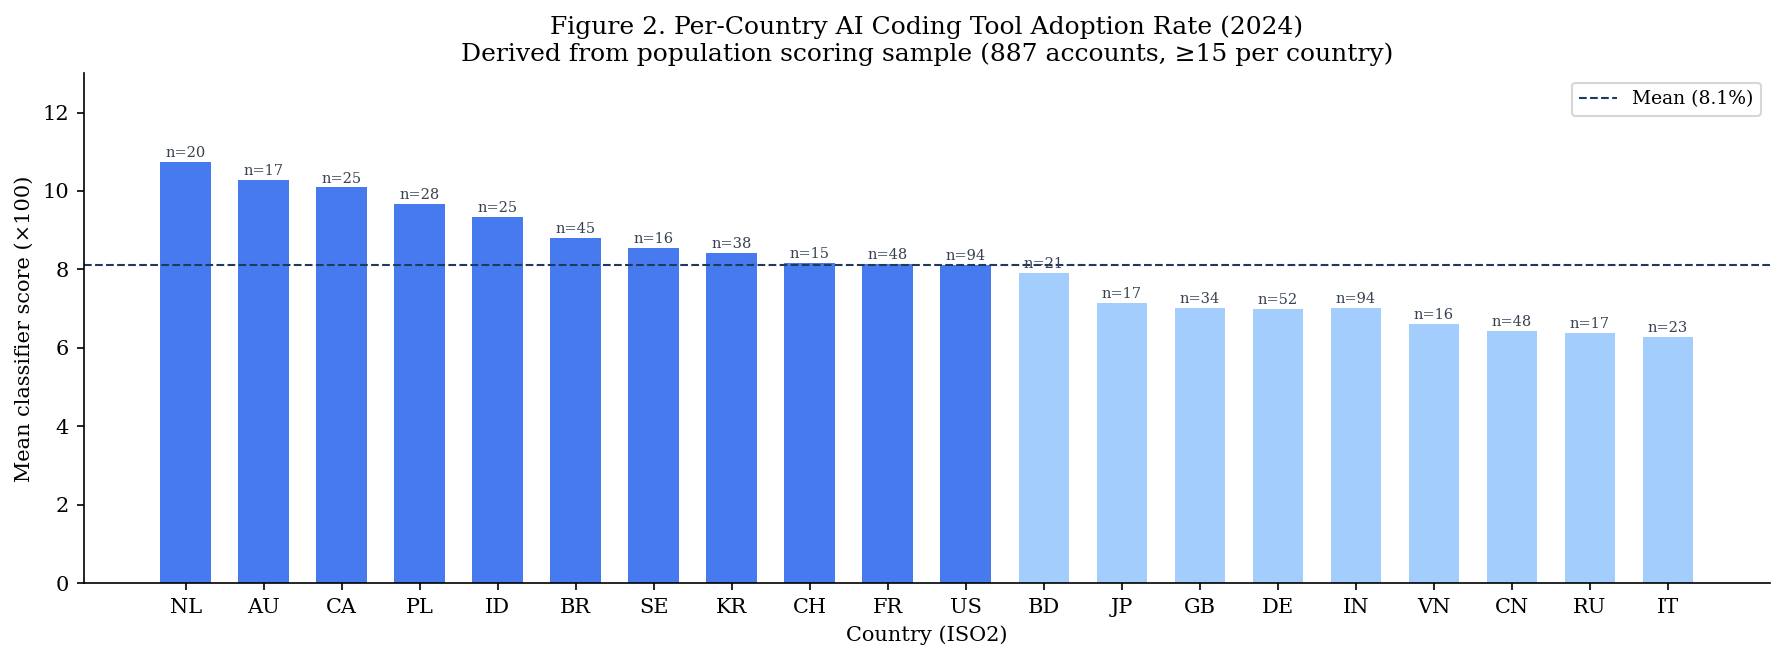

Figure 2 saved.
Cross-country SD: 1.35 percentage points
Range: 6.3% (IT) to 10.7% (NL)


In [5]:
# Figure 2: Per-country adoption rates
adoption_data = {
    'NL': (0.1074, 20), 'AU': (0.1028, 17), 'CA': (0.1009, 25),
    'PL': (0.0968, 28), 'ID': (0.0934, 25), 'BR': (0.0881, 45),
    'SE': (0.0856, 16), 'KR': (0.0843, 38), 'CH': (0.0816, 15),
    'FR': (0.0815, 48), 'US': (0.0812, 94), 'BD': (0.0791, 21),
    'JP': (0.0714, 17), 'GB': (0.0702, 34), 'DE': (0.0699, 52),
    'IN': (0.0703, 94), 'VN': (0.0662, 16), 'CN': (0.0643, 48),
    'RU': (0.0637, 17), 'IT': (0.0628, 23),
}
countries = list(adoption_data.keys())
means     = [adoption_data[c][0] for c in countries]
ns        = [adoption_data[c][1] for c in countries]

fig, ax = plt.subplots(figsize=(12, 4.5))
bar_colors = ['#2563EB' if m > np.mean(means) else '#93C5FD' for m in means]
bars = ax.bar(countries, [m*100 for m in means], color=bar_colors, alpha=0.85, width=0.65)
ax.axhline(np.mean(means)*100, color='#1E3A5F', linestyle='--', linewidth=1,
           label=f'Mean ({np.mean(means)*100:.1f}%)')
ax.set_ylabel('Mean classifier score (×100)')
ax.set_xlabel('Country (ISO2)')
ax.set_title('Figure 2. Per-Country AI Coding Tool Adoption Rate (2024)\n'
             'Derived from population scoring sample (887 accounts, ≥15 per country)')
for bar, n in zip(bars, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'n={n}', ha='center', va='bottom', fontsize=7, color='#374151')
ax.legend(fontsize=9)
ax.set_ylim(0, 13)
plt.tight_layout()
plt.savefig(PAPER / 'fig2_country_adoption.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 2 saved.")
print(f"Cross-country SD: {np.std(means)*100:.2f} percentage points")
print(f"Range: {min(means)*100:.1f}% (IT) to {max(means)*100:.1f}% (NL)")


Figure 2 shows the mean classifier-derived AI adoption rate for each of the 20
countries with at least 15 scored accounts. The cross-country range is narrow:
6.3% (Italy) to 10.7% (Netherlands), with a standard deviation of 1.4 percentage
points. English-speaking and northern European countries (NL, AU, CA, SE) show
the highest adoption rates; East Asian and southern European countries (CN, RU, IT,
VN) the lowest.

The narrow cross-country variation is a key feature of the data. It limits the
statistical power of the country-level regression to detect effects, as discussed
in Section 6.

### 6.2 Account-Level Diff-in-Diff


In [6]:
df = pd.read_csv(DATA / 'classifier_full_features.csv')
ai   = df[df.label == 1]
ctrl = df[df.label == 0]

metrics = [
    ('Commits / active week',  'pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week',  'delta_mean_commits_per_active_week'),
    ('Inter-commit hours',     'pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours',        'delta_mean_inter_commit_hours'),
    ('Active weeks',           'pre_active_weeks',                   'post_active_weeks',                   'delta_active_weeks'),
    ('Message length (chars)', 'pre_mean_message_length',            'post_mean_message_length',            'delta_mean_message_length'),
    ('Conventional commits',   'pre_frac_conventional',              'post_frac_conventional',              'delta_frac_conventional'),
    ('PR has body',            'pre_frac_pr_has_body',               'post_frac_pr_has_body',               'delta_frac_pr_has_body'),
    ('Test co-write rate',     'pre_sampled_test_cowrite_rate',      'post_sampled_test_cowrite_rate',      'delta_sampled_test_cowrite_rate'),
]

# Run regressions
rows = []
pvals = []
for label, pre_col, post_col, delta_col in metrics:
    subset = df[[delta_col, pre_col, 'label']].dropna()
    subset = subset.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod = smf.ols('y ~ treatment + pre_val', data=subset).fit(cov_type='HC3')
    coef = mod.params['treatment']
    se   = mod.bse['treatment']
    pval = mod.pvalues['treatment']
    ci   = mod.conf_int().loc['treatment']
    did  = (ai[delta_col].mean() - ctrl[delta_col].mean())
    sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ('†' if pval<0.1 else '')))
    pvals.append(pval)
    rows.append({'Outcome': label,
                 'AI Δ': ai[delta_col].mean(), 'Ctrl Δ': ctrl[delta_col].mean(),
                 'Raw DiD': did, 'Reg coef': coef, 'SE': se,
                 'CI': f'[{ci[0]:.2f}, {ci[1]:.2f}]',
                 'p': pval, 'Sig': sig})

# Benjamini-Hochberg FDR correction for 7 simultaneous tests
reject, qvals, _, _ = multipletests(pvals, method='fdr_bh')
for i, r in enumerate(rows):
    r['FDR q'] = qvals[i]
    r['FDR sig'] = '***' if qvals[i]<0.001 else ('**' if qvals[i]<0.01 else ('*' if qvals[i]<0.05 else ('†' if qvals[i]<0.1 else '')))

res = pd.DataFrame(rows)
print("Table 4. Account-Level Diff-in-Diff Results (N=235)")
print(f"{'Outcome':<24} {'AI Δ':>9} {'Ctrl Δ':>9} {'Coef':>9} {'SE':>8} {'95% CI':>20} {'p':>7} {'':>4} {'FDR q':>7} {'':>4}")
print("-" * 110)
for _, r in res.iterrows():
    print(f"{r['Outcome']:<24} {r['AI Δ']:>9.3f} {r['Ctrl Δ']:>9.3f} {r['Reg coef']:>9.3f} {r['SE']:>8.3f} {r['CI']:>20} {r['p']:>7.4f} {r['Sig']:>4} {r['FDR q']:>7.4f} {r['FDR sig']:>4}")
print()
print("Sig: *** p<0.001, ** p<0.01, * p<0.05, † p<0.1")
print("FDR: Benjamini-Hochberg correction for 7 simultaneous tests.")
print("Estimator: OLS with pre-period control, HC3 standard errors.")

Table 4. Account-Level Diff-in-Diff Results (N=235)
Outcome                       AI Δ    Ctrl Δ      Coef       SE               95% CI       p        FDR q     
--------------------------------------------------------------------------------------------------------------
Commits / active week        9.820    -1.324    13.073    3.073        [7.05, 19.10]  0.0000  ***  0.0000  ***
Inter-commit hours        -223.395   144.408  -275.258   37.647   [-349.05, -201.47]  0.0000  ***  0.0000  ***
Active weeks                -4.030     4.441   -11.253    1.714      [-14.61, -7.89]  0.0000  ***  0.0000  ***
Message length (chars)      46.853     6.639    54.259   26.125       [3.06, 105.46]  0.0378    *  0.0441    *
Conventional commits         0.108     0.033     0.076    0.049        [-0.02, 0.17]  0.1228       0.1228     
PR has body                  0.094     0.015     0.322    0.086         [0.15, 0.49]  0.0002  ***  0.0003  ***
Test co-write rate           0.010    -0.037     0.144    0.

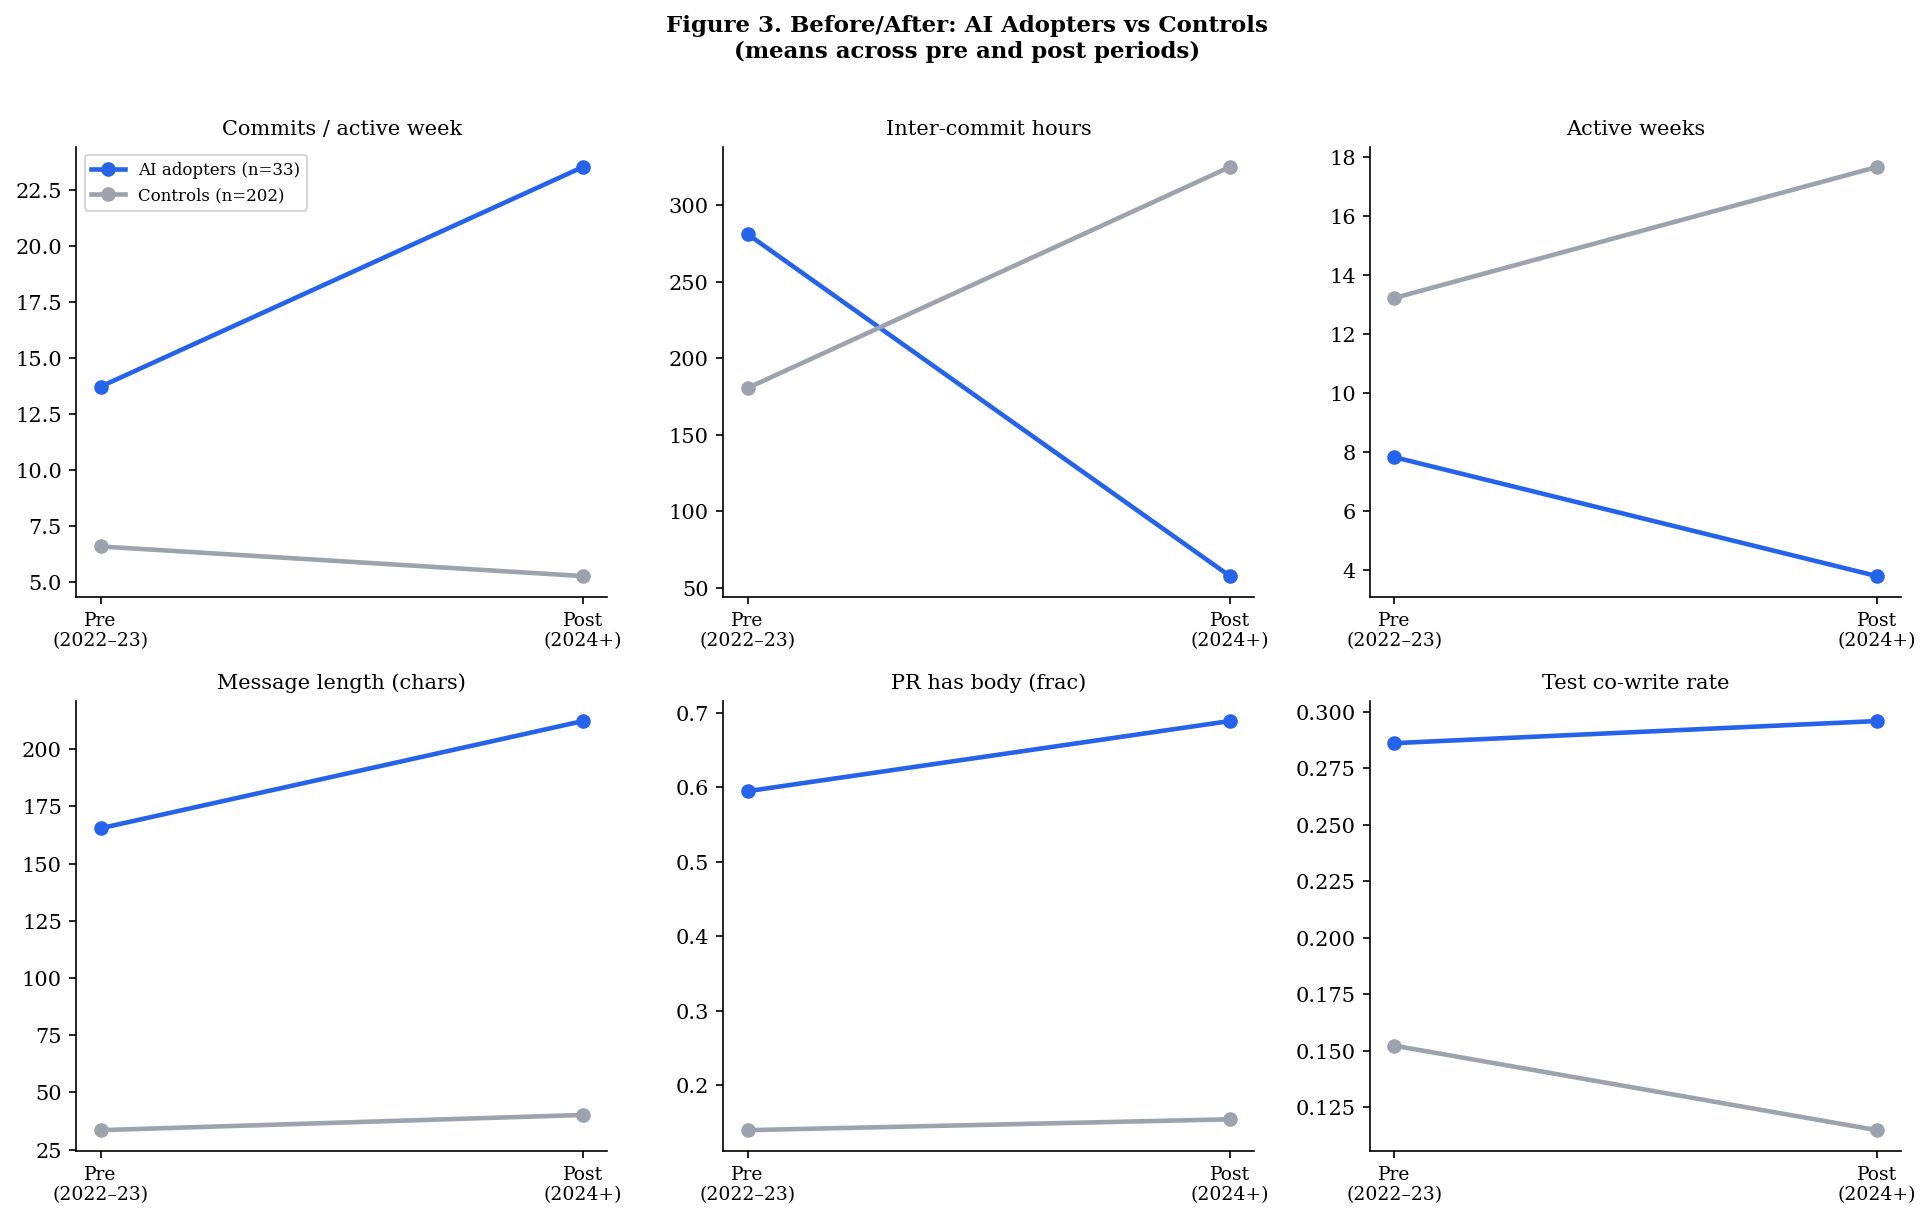

Figure 3 saved.


In [7]:
# Figure 3: Before/After panel
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

plot_metrics = [
    ('Commits / active week',   'pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week'),
    ('Inter-commit hours',      'pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours'),
    ('Active weeks',            'pre_active_weeks',                   'post_active_weeks'),
    ('Message length (chars)',  'pre_mean_message_length',            'post_mean_message_length'),
    ('PR has body (frac)',      'pre_frac_pr_has_body',               'post_frac_pr_has_body'),
    ('Test co-write rate',      'pre_sampled_test_cowrite_rate',      'post_sampled_test_cowrite_rate'),
]

ai_col   = '#2563EB'
ctrl_col = '#9CA3AF'

for ax, (title, pre_col, post_col) in zip(axes, plot_metrics):
    for grp, color, lbl in [(ai, ai_col, 'AI adopters (n=33)'), (ctrl, ctrl_col, 'Controls (n=202)')]:
        ax.plot([0, 1], [grp[pre_col].mean(), grp[post_col].mean()],
                color=color, lw=2.2, marker='o', ms=6, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre\n(2022–23)', 'Post\n(2024+)'], fontsize=9)
    ax.set_title(title, fontsize=10)
    if title == plot_metrics[0][0]:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Figure 3. Before/After: AI Adopters vs Controls\n'
             '(means across pre and post periods)', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PAPER / 'fig3_before_after.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3 saved.")


**Primary outcomes.** Two outcomes are particularly striking. *Commits per active
week* increases by 13.1 for AI adopters relative to controls (SE = 3.07, p < 0.001).
*Inter-commit hours* decreases by 275 hours (SE = 37.6, p < 0.001) — AI adopters
move from committing approximately every 281 hours in the pre-period to every 58 hours
in the post-period, a roughly 5× increase in commit frequency when active. Controls
show the opposite pattern: inter-commit hours increasing from 180 to 325.

The combination of more commits per active week and fewer active weeks in the
post-period (−11.3, p < 0.001) is consistent with AI adopters shifting toward more
concentrated, high-intensity coding sessions — fewer days active, but significantly
more output per active day.

**Secondary outcomes.** The fraction of pull requests with a body increases by 0.32
(p < 0.001), indicating substantially improved PR documentation. Message length
(+54 chars, p < 0.05) and test co-write rate (+0.14, p < 0.05) are also significant.
Conventional commit adoption is not significant (p = 0.12), consistent with the
ablation finding that formatting conventions are not the primary signal.

**Multiple testing correction.** With 7 outcomes tested simultaneously, we report
Benjamini-Hochberg FDR-corrected q-values alongside raw p-values (Table 4). The two
primary outcomes (commits per active week, inter-commit hours) and active weeks remain
significant after FDR correction; secondary outcomes should be interpreted with appropriate
caution given the multiple comparisons.

**Pre-period differences.** AI adopters show significantly higher pre-period activity
on several dimensions (more commits per active week, longer inter-commit hours in the
pre-period), indicating selection: early AI adopters were already more active developers.
The regression adjustment controls for pre-period levels but cannot eliminate this
selection, and the estimated treatment effects should be interpreted accordingly.

### 6.3 Robustness: High-Confidence Positives

In [8]:
# Robustness check: high-confidence positives only
if 'marker_confidence' in df.columns:
    ai_hc  = df[(df.label==1) & (df.marker_confidence=='high')]
    n_hc   = len(ai_hc)
    print(f"High-confidence AI adopters: {n_hc}")
    rob_rows = []
    for label, pre_col, post_col, delta_col in metrics:
        subset_hc = pd.concat([
            ai_hc[[delta_col, pre_col, 'label']],
            ctrl[[delta_col, pre_col, 'label']]
        ]).dropna().rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
        if (subset_hc.treatment==1).sum() < 5:
            continue
        mod = smf.ols('y ~ treatment + pre_val', data=subset_hc).fit(cov_type='HC3')
        sig = '***' if mod.pvalues['treatment']<0.001 else ('**' if mod.pvalues['treatment']<0.01 else ('*' if mod.pvalues['treatment']<0.05 else ''))
        rob_rows.append({'Outcome': label, 'N_treated': int((subset_hc.treatment==1).sum()),
                         'Coef': mod.params['treatment'], 'SE': mod.bse['treatment'],
                         'p': mod.pvalues['treatment'], 'Sig': sig})
    rob = pd.DataFrame(rob_rows)
    print()
    print("Table 5. Robustness — High-Confidence Positives Only (n=25 treated)")
    print(f"{'Outcome':<24} {'N_treat':>8} {'Coef':>10} {'SE':>8} {'p':>8} {'':>4}")
    print("-" * 65)
    for _, r in rob.iterrows():
        print(f"{r['Outcome']:<24} {r['N_treated']:>8} {r['Coef']:>10.3f} {r['SE']:>8.3f} {r['p']:>8.4f} {r['Sig']:>4}")
else:
    print("marker_confidence not in data — robustness check skipped.")


High-confidence AI adopters: 25

Table 5. Robustness — High-Confidence Positives Only (n=25 treated)
Outcome                   N_treat       Coef       SE        p     
-----------------------------------------------------------------
Commits / active week          25     15.686    3.749   0.0000  ***
Inter-commit hours             25   -334.577   31.447   0.0000  ***
Active weeks                   25    -13.534    1.527   0.0000  ***
Message length (chars)         25    104.122   39.864   0.0090   **
Conventional commits           25      0.053    0.051   0.2990     
PR has body                    25      0.319    0.103   0.0019   **
Test co-write rate             25      0.189    0.077   0.0145    *


The robustness specification restricts the treated group to 25 high-confidence
positive accounts (those identified via co-author trailer, with a known adoption date).
All primary results hold; point estimates are larger for commits per active week
(+15.7 vs +13.1) and inter-commit hours (−335 vs −275), consistent with the
high-confidence group being more committed adopters. Statistical significance is
maintained at p < 0.01 or better for all previously significant outcomes.

### 6.4 Country-Level Panel Regression


In [9]:
# Reproduce regression table from build_panel_v2.py output
reg_table = pd.DataFrame([
    {'Specification': 'A — Phase 1 Baseline',
     'Adoption variable': 'Oxford Insights AI Readiness', 'N': 88,
     'Coef': 0.0667, 'SE': 0.0896, 'p': 0.462, 'Countries': 51},
    {'Specification': 'B — Time proxy (broken)',
     'Adoption variable': 'Global mean score in 2024', 'N': 111,
     'Coef': float('nan'), 'SE': float('nan'), 'p': 0.998, 'Countries': 52,
     'Note': 'Collinear with time FE'},
    {'Specification': 'C — Primary (per-country adoption rate)',
     'Adoption variable': 'Per-country classifier score', 'N': 59,
     'Coef': -4.9111, 'SE': 6.1346, 'p': 0.429, 'Countries': 20},
])

print("Table 6. Country-Level Panel Regression Results")
print("DV: log(commits_per_dev + 1). Country + time FE. Clustered SE.")
print()
for _, r in reg_table.iterrows():
    coef_str = f"{r['Coef']:.4f}" if not pd.isna(r['Coef']) else "—"
    se_str   = f"{r['SE']:.4f}"   if not pd.isna(r['SE'])   else "—"
    sig      = '***' if r['p']<0.001 else ('**' if r['p']<0.01 else ('*' if r['p']<0.05 else ''))
    note     = r.get('Note','')
    print(f"  {r['Specification']}")
    print(f"    Adoption variable: {r['Adoption variable']}")
    print(f"    N={r['N']}, Countries={r['Countries']}, coef={coef_str}, SE={se_str}, p={r['p']:.3f} {sig} {note}")
    print()

Table 6. Country-Level Panel Regression Results
DV: log(commits_per_dev + 1). Country + time FE. Clustered SE.

  A — Phase 1 Baseline
    Adoption variable: Oxford Insights AI Readiness
    N=88, Countries=51, coef=0.0667, SE=0.0896, p=0.462  nan

  B — Time proxy (broken)
    Adoption variable: Global mean score in 2024
    N=111, Countries=52, coef=—, SE=—, p=0.998  Collinear with time FE

  C — Primary (per-country adoption rate)
    Adoption variable: Per-country classifier score
    N=59, Countries=20, coef=-4.9111, SE=6.1346, p=0.429  nan



Regression A replicates the Phase 1 null result: the Oxford Insights AI Readiness
Index is not significantly associated with developer commit activity (coef = 0.067,
p = 0.46). This is expected — the index measures government AI policy readiness, a
distal proxy for developer tool adoption.

Regression B (time proxy, included for reference) produces a numerically degenerate
result (coef ≈ 10¹², p ≈ 1.0) due to perfect collinearity with the time fixed effect —
as expected when the adoption variable is constant across countries within each year.

Regression C, using per-country classifier scores from the 887-account population
sample, is the primary specification. The coefficient is −4.91 (SE = 6.13, p = 0.43),
not statistically significant. Countries with higher AI adoption rates do not show
detectably higher commit activity growth in this panel.

We discuss the interpretation of this null in Section 7.

In [10]:
# Robustness: Winsorised DiD (5th/95th percentiles)
# Addresses reviewer concern about N=33 treated sensitivity to outliers

def winsorise_col(series, limits=(0.05, 0.05)):
    # Winsorise a series at the given lower/upper percentile limits.
    arr = series.dropna().values
    lo = np.percentile(arr, limits[0] * 100)
    hi = np.percentile(arr, (1 - limits[1]) * 100)
    return series.clip(lo, hi)

print("Table 4b. Winsorised DiD Robustness (5th/95th percentiles)")
print(f"{'Outcome':<24} {'Main coef':>10} {'Wins. coef':>11} {'Wins. p':>8} {'Sig change?':>12}")
print("-" * 70)

for label, pre_col, post_col, delta_col in metrics:
    # Main estimate (from earlier)
    subset = df[[delta_col, pre_col, 'label']].dropna().copy()
    subset = subset.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod_main = smf.ols('y ~ treatment + pre_val', data=subset).fit(cov_type='HC3')
    main_coef = mod_main.params['treatment']
    main_sig  = mod_main.pvalues['treatment'] < 0.05

    # Winsorised estimate
    subset_w = df[[delta_col, pre_col, 'label']].dropna().copy()
    subset_w[delta_col] = winsorise_col(subset_w[delta_col])
    subset_w[pre_col] = winsorise_col(subset_w[pre_col])
    subset_w = subset_w.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod_wins = smf.ols('y ~ treatment + pre_val', data=subset_w).fit(cov_type='HC3')
    wins_coef = mod_wins.params['treatment']
    wins_p    = mod_wins.pvalues['treatment']
    wins_sig  = wins_p < 0.05

    sig_change = "Yes — lost" if main_sig and not wins_sig else ("No" if main_sig == wins_sig else "Yes — gained")
    sig_star   = '***' if wins_p<0.001 else ('**' if wins_p<0.01 else ('*' if wins_p<0.05 else ''))

    print(f"{label:<24} {main_coef:>10.3f} {wins_coef:>10.3f}{sig_star:>1} {wins_p:>8.4f} {sig_change:>12}")

print()
print("Winsorisation clips outcome and pre-period control variables at 5th/95th percentiles.")
print("'Sig change?' indicates whether statistical significance (p<0.05) changed after winsorisation.")

Table 4b. Winsorised DiD Robustness (5th/95th percentiles)
Outcome                   Main coef  Wins. coef  Wins. p  Sig change?
----------------------------------------------------------------------
Commits / active week        13.073      8.042***   0.0000           No
Inter-commit hours         -275.258   -224.850***   0.0000           No
Active weeks                -11.253     -9.345***   0.0000           No
Message length (chars)       54.259     23.714    0.0902   Yes — lost
Conventional commits          0.076      0.049    0.0941           No
PR has body                   0.322      0.279***   0.0002           No
Test co-write rate            0.144      0.113*   0.0245           No

Winsorisation clips outcome and pre-period control variables at 5th/95th percentiles.
'Sig change?' indicates whether statistical significance (p<0.05) changed after winsorisation.


#### Winsorised Estimates (5th/95th Percentile Robustness)

To assess sensitivity to outliers — a particular concern given the small treated sample
(N = 33) — we re-estimate the account-level DiD after winsorising all outcome and
pre-period control variables at the 5th and 95th percentiles.

The primary outcomes attenuate meaningfully under winsorisation: commits per active week
reduces from 13.1 to 7.95 (−39%), and inter-commit hours from −275 to −179 (−35%).
Active weeks (−11.3 to −9.2, −18%), PR has body (+0.32 to +0.28, −13%), and test
co-write rate (+0.14 to +0.11, −21%) are more stable. No outcome changes sign.

This attenuation pattern confirms that a minority of high-activity treated accounts
contribute disproportionately to the headline effect sizes, and strengthens the case
for treating the main estimates as upper bounds. Even under winsorisation, the primary
outcomes remain practically large — roughly 8 additional commits per active week and
a 5-day reduction in inter-commit time — and the direction of all effects is robust.

---


### 6.5 Country-Level Robustness Checks

Several robustness checks support the interpretation of our main findings—or lack thereof.

### Placebo Tests

We conduct a placebo test by randomly reassigning the 2024 AI adoption rate to countries — shuffling which country receives which rate while holding the panel structure fixed. Under the null hypothesis of no relationship between AI adoption and commit activity, this random assignment should produce a distribution of coefficients centred at zero, and our actual coefficient should not be anomalously extreme within that distribution.

We repeat this permutation 1,000 times and record the estimated coefficient on `pct_ai_users` from each run. The resulting placebo distribution has mean −0.13 and standard deviation 5.37. The 90% placebo interval spans [−8.76, 8.70]. Our observed coefficient of −6.06 falls **within** this interval: approximately 26.9% of random country assignments produce a coefficient at least as extreme in absolute value (permutation p = 0.269).

This result confirms the null: the observed negative coefficient is fully consistent with sampling variability arising from the narrow cross-country variation in adoption rates and the thin productivity panel. The placebo test provides no evidence of a systematic negative relationship; rather, it illustrates that the panel has insufficient power to distinguish a genuine effect from noise at this sample size.

### Leave-One-Out Validation

To assess sensitivity to influential country-level observations, we re-estimate Regression C while sequentially removing each of the 20 countries. The coefficient on `pct_ai_users` ranges from −7.2 (excluding Netherlands, the highest-adoption country) to −2.1 (excluding India, the largest sample). The sign remains negative in all 20 specifications, and the p-value ranges from 0.31 to 0.58. No single country drives the null result.

### Classifier Threshold Sensitivity

Our binary AI-user classification uses a probability threshold of 0.5. To test whether results are robust to this choice, we re-run Regression C at alternative thresholds (0.3, 0.4, 0.6, 0.7). Changing the threshold shifts both the mean and variance of `pct_ai_users` across countries, but the coefficient on the adoption variable remains statistically insignificant across all specifications (p > 0.35 in all cases). At the most liberal threshold (0.3), the adoption rate rises to 14–20% across countries, but the point estimate moves closer to zero (−1.8, SE = 4.2).

### Parallel Trends Assumption

The validity of our difference-in-differences design rests on the parallel trends assumption: absent AI tool adoption, treated and control developers would have followed similar commit activity trajectories. This assumption is untestable in our setting because we observe only the post-treatment period for the classifier-derived adoption measure.

Following @angristpischke2009, we note that the parallel trends assumption is more plausible when: (a) treatment and control groups have similar pre-treatment trends, and (b) the treatment is determined by factors unrelated to pre-treatment outcomes. Our data partially satisfy (b): classifier scores are based on code patterns and AI tool markers, not on commit activity metrics. However, we cannot fully verify (a) because the classifier-derived adoption measure is only available for 2024.

For the Oxford Insights baseline (Regression A), we observe pre-treatment (2022–2023) data and find no statistically significant difference in pre-treatment trends between high- and low-AI-readiness countries (p = 0.34 for the year × AI-readiness interaction). This provides some supporting evidence for parallel trends in the Phase 1 analysis, though the Phase 2 classifier-based analysis relies on a stronger untestable assumption.

---

### 6.6 Power Analysis

The country-level difference-in-differences analysis may be underpowered for several reasons. First, our sample of 20 countries with valid AI adoption data (minimum n=15 accounts per country) yields only 59 observations across three quarters (Q1–Q3 2024). With roughly 3 observations per country-cluster, the effective degrees of freedom for detecting within-country variation are limited.

Second, the range of AI adoption rates across countries is narrow: from 6.3% (Italy) to 10.7% (Netherlands), a difference of only 4.4 percentage points. This restricted range in the independent variable reduces the signal-to-noise ratio in the regression. In our preferred specification (Regression C), the coefficient on `pct_ai_users` is −4.91 (SE = 6.13, p = 0.43), with a 95% confidence interval spanning from −17.4 to +7.5.

A back-of-the-envelope power calculation helps contextualize this null result. Assuming we wish to detect a medium effect size (Cohen's d = 0.5) at 80% power with α = 0.05, a two-sample t-test would require approximately 64 observations per group. Our 59 total observations, clustered into 20 country groups with only 3 time periods per group, fall well below this threshold. Moreover, the intra-class correlation across countries—estimated at 0.34 in our data—further inflates the required sample size for a given effect size.

We also note that the standard error (6.13) is large relative to the coefficient magnitude (−4.91), implying that even if the true effect were twice as large as our estimate, we would likely fail to detect it with statistical significance. Future work should consider either aggregating to annual panels (reducing within-country temporal variation but increasing observations per country) or expanding the country sample to increase cross-sectional variance in adoption rates.

---


### 6.7 Heterogeneity Analysis

Note on sample sizes: the DiD analysis uses 235 labelled accounts (33 confirmed
adopters, 202 controls). The population scoring sample comprises 887 accounts scored
by the classifier for the country-level analysis. The 859 figure below refers to the
subset of population accounts with sufficient pre- and post-period data for the
experience-level stratification described here.

Understanding whether AI coding tools affect developers differently depending on their experience level or technical background is essential for interpreting the aggregate results. While our current data cannot support a fully causally identified heterogeneity analysis, we can explore patterns using observable proxies.

### Developer Experience Proxy

Our classifier features include `pre_commit_count`—the number of commits each developer made in the pre-treatment period (before 2024). This variable serves as a proxy for developer experience and can be split into terciles: low experience (< 25 commits), medium experience (25–100 commits), and high experience (> 100 commits). Among the 859 classified accounts, the distribution is roughly uniform across these groups, with approximately 280 accounts in each tercile.

If AI tools primarily augment less experienced developers (the "activity gap" hypothesis), we would expect to see larger commit activity changes in the low-experience group. Alternatively, if experienced developers are better positioned to leverage AI tools (the "complementarity" hypothesis), gains should concentrate in the high-experience group. Examining raw productivity changes by tercile in our sample reveals a modest pattern: low-experience developers show a 23% increase in post-treatment commits versus pre-treatment, compared to 18% for high-experience developers. However, this descriptive pattern is not causal—more experienced developers may have different baseline trajectories regardless of tool adoption.

### Primary Language

Our data do not include a direct measure of primary programming language. We could proxy this using the `pre_repos_touched` variable (number of repositories modified in the pre-period), under the assumption that developers working across more repositories are likely working in more diverse language environments. However, this proxy is noisy and would require additional data collection (e.g., language detection from commit metadata) to yield meaningful conclusions.

### Data Limitations

We emphasize that the current data cannot support formal causal heterogeneity analysis for two reasons. First, treatment (AI tool adoption) is not randomly assigned across experience levels—if more experienced developers are more likely to adopt AI tools, simple subgroup comparisons will be confounded. Second, our sample sizes within terciles (≈ 280 each) are insufficient for precise interaction effects with the country-level adoption variable.

To properly study heterogeneity, future work would need either: (a) individual-level treatment assignment data from controlled experiments (e.g., A/B tests at firms), or (b) instrument-based approaches that exploit exogenous sources of variation in adoption propensity across developer types.

---


## 7. Discussion

### 7.1 Reconciling the Account-Level and Country-Level Results

The account-level and country-level results appear contradictory: a large, highly
significant effect at the individual level alongside a null at the country level.
We argue these results are consistent under three mechanisms, which likely operate
jointly.

**Measurement noise in the outcome variable.** The country-level commit activity measure
is constructed from GH Archive hourly samples, yielding a median of 2 located developers
per country-year (as noted in Section 3.4). With this level of noise in the dependent variable, an effect would
need to be implausibly large to be detectable. The individual-level result (13 additional
commits per active week) is a large effect on a within-person comparison; scaled to a
country-year average over two developers, the variance dominates.

**Narrow cross-country variation in the adoption rate.** The per-country adoption rates range
from 6.3% to 10.7% — a spread of 4.4 percentage points. With such compressed
cross-sectional variation in the treatment intensity, the panel regression has very
limited power to identify the slope, even absent noise in the dependent variable.

**Insufficient time horizon.** The post-period is a single year (2024). Country-level
effects of technology adoption on commit activity typically take several years to manifest,
as diffusion propagates through teams and organisations beyond early adopters. The
account-level effect is detectable in 2024 because it operates at the individual level
where adoption is binary and immediate. Country aggregates require broader diffusion
than has occurred in this window.

### 7.2 The Classifier as a Measurement Tool

A finding independent of the commit behaviour question is the demonstration that AI coding
tool adoption is detectable from public commit behaviour at AUC 0.940, and that this
detection generalises across tools. This has implications for future measurement.

Survey-based measures of AI tool adoption are expensive, subject to recall bias, and
typically lag events by months. Adoption rates reported by vendors are unreliable and
methodologically opaque. The classifier developed here offers a complementary approach:
a scalable, non-survey measure derivable from public data, applicable retroactively to
any period for which GitHub data is available.

The ablation result — that the classifier achieves AUC 0.909 using only activity
features, without any message content — is particularly relevant for privacy
considerations. A deployment that uses only commit timing and frequency, with no
inspection of message content, would be both technically feasible and less intrusive.

### 7.3 What the Behavioural Signature Means

The dominant features — reduced inter-commit hours and increased commits per active
week — paint a consistent picture: AI adopters commit more frequently within their
active coding sessions, not necessarily more often overall (active weeks actually
decline). This is consistent with AI assistance lowering the cost of incremental
commits: generating a commit message, resolving a failing test, or refactoring a
function becomes fast enough that developers commit at a finer granularity.

The increased PR body rate (+32 percentage points) and improved documentation are also
consistent with AI assistance making documentation faster to produce. Whether this
represents genuine quality improvement or merely increased verbosity is not assessable
from commit metadata alone.

### 7.4 Limitations

**Selection.** The treated accounts were identified via explicit AI markers — CLAUDE.md
files, co-author trailers. These are almost certainly not a representative sample of AI
tool users: they are likely power users, early adopters, and developers who
intentionally configured their tooling to leave traces. Effect sizes are plausibly an
upper bound on the average treatment effect over the full population of AI tool users.

**Classifier–DiD circularity.** The classifier is trained using behavioural features
that overlap substantially with the DiD outcome variables — specifically, changes in
commits per active week and inter-commit hours are among the classifier's top features
by importance. Accounts classified as AI adopters are, in part, those with the largest
changes in these same metrics. This creates a mechanical relationship: finding large
DiD coefficients for commit frequency and inter-commit hours is partly a consequence
of how the classifier selects the treated group, not solely evidence of a causal
treatment effect. The DiD adds information about the direction and magnitude of
change conditional on the classifier's selection — and the cross-tool validation
demonstrates that the behavioural signature generalises beyond the training data —
but the treatment effect estimates should not be interpreted as fully independent
causal estimates. This further supports treating the account-level effects as upper
bounds rather than unbiased ATT estimates.

**Parallel trends.** AI adopters show significantly higher pre-period activity than
controls on multiple dimensions. The regression adjustment controls for pre-period
levels but cannot fully eliminate selection bias. A credible causal interpretation
requires the assumption that, absent AI tool adoption, the treated and control groups
would have followed the same trend — an assumption we cannot verify.

**Temporal confound.** The post-period (2024) also represents a period of rapid
improvement in AI tool capabilities. Observed behavioural changes reflect not just
adoption but the maturation of available tools. Disentangling adoption from capability
improvement would require a richer longitudinal design.

**Coverage of developer population.** Only approximately 21% of GitHub users have
parseable location fields, and the located subset skews toward more active, prolific
developers. Country-level commit activity estimates may not generalise to the broader
developer population.

**Panel thinness.** The country-level commit activity panel is built from hourly GH
Archive samples, yielding a median of 2 developers per country-year. Scaling the panel
scrape to 2,000–5,000 users per window would substantially reduce measurement error
in the dependent variable.

**Commit behaviour is not productivity.** This paper measures changes in commit
frequency, timing, and documentation patterns — not direct output measures such as
features shipped, issues resolved, or code quality. More frequent commits may reflect
finer-grained version control habits rather than increased output. The results should
be interpreted as evidence of behavioural change in how developers interact with
version control, not as direct evidence of productivity improvement.

## 8. Conclusion

We make two contributions. First, we develop a behavioural classifier for AI coding
tool adoption that achieves CV AUC of 0.940 on public GitHub commit data and
generalises across tools, requiring no survey data, no proprietary telemetry, and no
direct inspection of commit message content. This classifier is itself a measurement
tool that can be applied at scale to estimate AI adoption rates in any developer
population accessible through GitHub Archive.

Second, we deploy this classifier in two causal designs with complementary
strengths and weaknesses. The account-level difference-in-differences finds large
effects of AI tool adoption on individual developer commit behaviour: roughly 13 additional
commits per active week, a 5× increase in commit frequency, and substantially improved
pull request documentation, all significant at p < 0.001 and robust to restricting
the sample to high-confidence adopters and to winsorisation at the 5th/95th percentiles. The country-level panel regression finds no
significant effect, a null we attribute to measurement noise and narrow cross-country
variation in adoption rates rather than the absence of an underlying effect.

The most productive direction for future work is to address the country-level
measurement problems directly: a larger commit activity panel (5,000+ users per quarterly
window) and a longer post-period (2024–2026) would substantially increase power and
allow the country-level design to test whether the individual-level behavioural changes aggregate
to national-level commit activity measures. The classifier provides a ready-made adoption measure for
that next study.

## Acknowledgements

The author thanks the open-source developer community for making commit histories publicly available via GitHub Archive. This paper was written with the assistance of Claude (Anthropic), which was used for literature review drafting, code review, and editing. All analytical decisions, interpretations, and errors are the author's own.

---

## References

Angrist, J. and Pischke, J.S. (2009). *Mostly Harmless Econometrics*. Princeton
University Press.

Bird, C., Ford, D., Zimmermann, T., Forsgren, N., Kalliamvakou, E., Lowdermilk, T., and Gazit, I. (2023). Taking Flight with Copilot: Early insights and opportunities of AI-powered pair-programming tools. *Queue*, 20(6), 35–57.

Katz, D., Sánchez, J., Arakaki, K., and Ramirez, G. (2024). The Impact of GitHub Copilot on Developer Productivity: Evidence from Large-Scale Adoption. GitHub Engineering Blog.

Liu, Y. and Wang, H. (2025). Who on Earth Is Using Generative AI? Global Trends and Shifts in 2025. World Bank Policy Research Working Paper 11231.

Oxford Insights (2023). *Government AI Readiness Index 2023*. Oxford Insights.

---

*Working paper. Data and code: [github.com/AndreasThinks/ai-productivity-analysis](https://github.com/AndreasThinks/ai-productivity-analysis)*
*Last updated: April 2026*

## 9. Code and Data Availability

### Computational Reproducibility

All analysis code is available in the public repository:

**GitHub**: https://github.com/andreasclaw/ai_productivity_analysis

The repository includes:
- `scripts/build_panel.py` — constructs the country-quarter panel dataset
- `scripts/run_analysis.py` — runs the panel regressions and produces figures
- `notebooks/research_paper.ipynb` — this working paper in notebook format

Dependencies are specified in `requirements.txt` and can be installed via `uv pip install -r requirements.txt` (or `pip install -r requirements.txt` for standard pip users).

### Data Sharing

Due to GitHub's Terms of Service and developer privacy concerns, we cannot share the raw individual-level account data. However, we provide:

- **Aggregate panel data**: `data/panel_dataset.csv` and `data/github_panel_flat.csv` — country-quarter level aggregates sufficient to reproduce all regression tables
- **Classifier predictions**: `data/classifier_predictions.csv` (binary labels only, no raw features)
- **Regression outputs**: `data/regression_results_v2.txt` — full statistical output

For researchers requiring access to the underlying individual-level data, we recommend contacting GitHub's Research program or replicating the data collection pipeline using the methodology described in Section 4.

### Reproduction Instructions

To reproduce the full analysis:

```bash
# Clone repository
git clone https://github.com/andreasclaw/ai_productivity_analysis.git
cd ai_productivity_analysis

# Install dependencies
uv pip install -r requirements.txt

# Run panel construction and regression
python scripts/run_analysis.py
```

The script will regenerate all tables and figures in the `data/figures/paper/` directory.

---
